# Statistiques d'annotation — comparaison multi-corpus (article)

**Volumes & distributions** : CSV/XLSX `dataset/data_<corpus>.*` (labels pass-1 migrés).

**Accord inter-annotateurs** : apparie `annotation/outputs/run_all_*` (`gpt-5.4-nano`)
avec `run_partial_*` (`gpt-5-nano`, **full corpus IAA v2**) → Observed agreement,
Cohen's κ (IC 95 %), matrices de confusion, export LaTeX.

Palette unique (Okabe–Ito) pour le barplot de distribution et les heatmaps de confusion.

### Lancer la double annotation full v2 (avant la section accord)

```bash
python scripts/run_annotation_batch.py pipeline --config configs/annotation_batch_pass1_v13_partial_btp.yaml
python scripts/run_annotation_batch.py pipeline --config configs/annotation_batch_pass1_v13_partial_metallurgie.yaml
python scripts/run_annotation_batch.py pipeline --config configs/annotation_batch_pass1_v13_partial_caou_chimie_plas.yaml
python scripts/run_annotation_batch.py pipeline --config configs/annotation_batch_pass1_v13_partial_nicollin.yaml
```


In [1]:
import os
import sys
from pathlib import Path


def _notebook_find_text_root(start: Path) -> Path:
    here = start.resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "safer_core" / "paths.py").is_file():
            return candidate
        nested = candidate / "text"
        if (nested / "safer_core" / "paths.py").is_file():
            return nested
    raise FileNotFoundError(
        "Racine text/ introuvable (safer_core/paths.py). "
        "Ouvrez Jupyter depuis le dossier text/ ou SAFER/."
    )


TEXT_ROOT = _notebook_find_text_root(Path.cwd())
if str(TEXT_ROOT) not in sys.path:
    sys.path.insert(0, str(TEXT_ROOT))
os.chdir(TEXT_ROOT)


In [2]:
# --- Paramètres ---
from pathlib import Path

DATASET_DIR = TEXT_ROOT / "dataset"
OUTPUTS_DIR = TEXT_ROOT / "annotation" / "outputs"
ONLY_CORPUS_IDS = None  # ex. ["btp", "metallurgie"] ou None = tous les data_*.csv
N_BOOT = 2000  # bootstrap IC 95 % sur κ (niveau récit)
BOOT_SEED = 42

print("DATASET_DIR =", DATASET_DIR)
print("OUTPUTS_DIR =", OUTPUTS_DIR)


DATASET_DIR = C:\Users\aho\Documents\analysis factor project\SAFER\text\dataset
OUTPUTS_DIR = C:\Users\aho\Documents\analysis factor project\SAFER\text\annotation\outputs


In [3]:
# --- Découverte des corpus dataset/ ---
from IPython.display import display

from annotation.article_stats import (
    ARTICLE_PLOT_COLORS,
    article_confusion_cmap,
    article_plot_colors,
    build_label_distribution_long,
    build_summary_table,
    discover_dataset_corpora,
)

all_datasets = discover_dataset_corpora(DATASET_DIR)
if ONLY_CORPUS_IDS:
    allowed = set(ONLY_CORPUS_IDS)
    datasets = [d for d in all_datasets if d["corpus_id"] in allowed]
else:
    datasets = all_datasets

if not datasets:
    raise FileNotFoundError(
        f"Aucun dataset/data_*.csv/.xlsx dans {DATASET_DIR}.\n"
        "Migrez d'abord : python scripts/migrate_annotation_to_dataset.py"
    )

print(f"{len(datasets)} corpus trouvé(s) :")
for d in datasets:
    print(f"  - {d['corpus']} ({d['corpus_id']})")
    print(f"    → {d['annotated_path'].name}")

# Alias pour compatibilité avec les cellules suivantes / exports.
runs = datasets


4 corpus trouvé(s) :
  - Construction (btp)
    → data_btp.csv
  - Chemistry--plastics (caou)
    → data_caou.csv
  - Metallurgy (metallurgie)
    → data_metallurgie.csv
  - Company corpus (nicollin)
    → data_nicollin.csv


In [4]:
# --- Tableau récapitulatif volumes (article) ---
summary_table = build_summary_table(datasets, include_overall=True)

display_cols = [
    "corpus",
    "n_recits",
    "n_units",
    "n_annotated",
    "pct_A0",
    "pct_A1",
    "pct_B",
    "pct_C",
]
article_table = summary_table[display_cols].copy()
article_table = article_table.rename(
    columns={
        "corpus": "Corpus",
        "n_recits": "Narratives (≥1 ok)",
        "n_units": "Nb unités factuelles",
        "n_annotated": "Nb annotées (pred_ok)",
        "pct_A0": "% A0",
        "pct_A1": "% A1",
        "pct_B": "% B",
        "pct_C": "% C",
    }
)

print("Tableau synthèse (pour article) — source : dataset/")
display(article_table)

summary_table


Tableau synthèse (pour article) — source : dataset/


,Corpus,Narratives (≥1 ok),Nb unités factuelles,Nb annotées (pred_ok),% A0,% A1,% B,% C
0,Construction,6040,42309,42244,54.21,11.01,18.07,16.71
1,Chemistry--plastics,838,6178,6157,56.02,11.06,15.17,17.75
2,Metallurgy,3212,22487,22456,55.78,10.23,16.30,17.69
3,Company corpus,5669,9577,9539,32.38,2.13,30.51,34.98
4,Overall,15759,80551,80396,52.20,9.74,18.83,19.23


,corpus,n_recits,n_units,n_annotated,n_missing_or_failed,pct_A0,pct_A1,pct_B,pct_C,n_A0,n_A1,n_B,n_C
0,Construction,6040,42309,42244,65,54.21,11.01,18.07,16.71,22899,4652,7635,7058
1,Chemistry--plastics,838,6178,6157,21,56.02,11.06,15.17,17.75,3449,681,934,1093
2,Metallurgy,3212,22487,22456,31,55.78,10.23,16.30,17.69,12527,2297,3660,3972
3,Company corpus,5669,9577,9539,38,32.38,2.13,30.51,34.98,3089,203,2910,3337
4,Overall,15759,80551,80396,155,52.20,9.74,18.83,19.23,41964,7833,15139,15460


In [5]:
# --- Distribution des classes (données longues, sans Overall) ---
dist_long = build_label_distribution_long(datasets)
dist_long


,corpus,run_id,label,n_units,pct
0,Construction,dataset_btp,A0,22899,54.21
1,Construction,dataset_btp,A1,4652,11.01
2,Construction,dataset_btp,B,7635,18.07
3,Construction,dataset_btp,C,7058,16.71
4,Chemistry--plastics,dataset_caou,A0,3449,56.02
5,Chemistry--plastics,dataset_caou,A1,681,11.06
6,Chemistry--plastics,dataset_caou,B,934,15.17
7,Chemistry--plastics,dataset_caou,C,1093,17.75
8,Metallurgy,dataset_metallurgie,A0,12527,55.78
9,Metallurgy,dataset_metallurgie,A1,2297,10.23


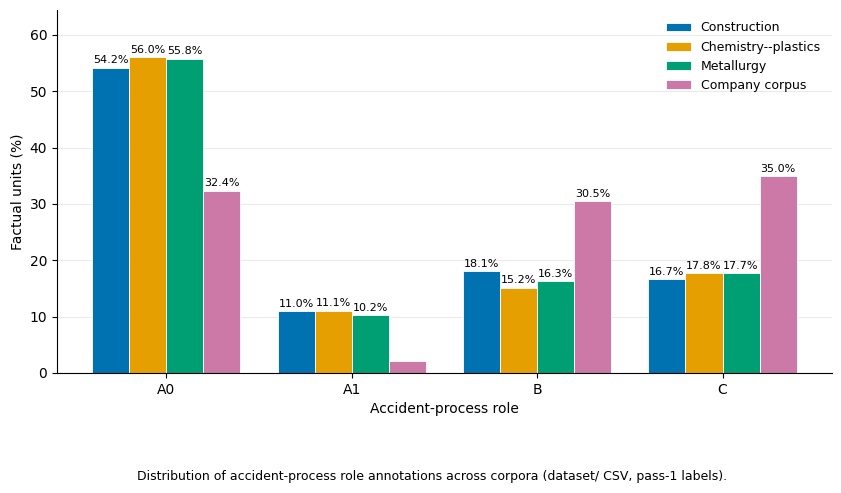

In [6]:
# --- Graphique : % par classe, comparaison des corpus (figure article) ---
import matplotlib.pyplot as plt
import numpy as np

if dist_long.empty:
    raise ValueError("Aucune distribution à tracer.")

dist_plot = dist_long.copy()
corpora = list(dict.fromkeys(dist_plot["corpus"]))
labels = ["A0", "A1", "B", "C"]
x = np.arange(len(labels))
width = 0.8 / max(len(corpora), 1)
colors = article_plot_colors(len(corpora))

fig, ax = plt.subplots(figsize=(10, 5.5))

for i, corpus in enumerate(corpora):
    subset = (
        dist_plot[dist_plot["corpus"] == corpus]
        .set_index("label")
        .reindex(labels)
    )
    offset = (i - (len(corpora) - 1) / 2) * width
    bars = ax.bar(
        x + offset,
        subset["pct"].values,
        width=width,
        label=corpus,
        color=colors[i],
        edgecolor="white",
        linewidth=0.6,
    )
    for bar, pct in zip(bars, subset["pct"].values):
        if pct >= 3:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.4,
                f"{pct:.1f}%",
                ha="center",
                va="bottom",
                fontsize=8,
            )

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Factual units (%)")
ax.set_xlabel("Accident-process role")
ax.legend(loc="upper right", fontsize=9, frameon=False)
ax.set_ylim(0, max(dist_plot["pct"].max() * 1.15, 10))
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.subplots_adjust(bottom=0.22)
fig.text(
    0.5,
    0.02,
    "Distribution of accident-process role annotations across corpora "
    "(dataset/ CSV, pass-1 labels).",
    ha="center",
    va="bottom",
    fontsize=9,
)
plt.show()


## Inter-annotator agreement

Jointure `(accident_id, fact_id)` entre `run_all_*` et `run_partial_*` (même corpus).
Métriques : observed agreement, Cohen's κ multiclasse (IC 95 % bootstrap au niveau récit),
effectifs par rôle (`n_A0`…`n_C` selon labels `run_all` sur l'échantillon apparié),
et matrices de confusion (`run_all` × `run_partial`).


In [7]:
# --- Accord run_all (gpt-5.4-nano) vs run_partial full v2 (gpt-5-nano) ---
import pandas as pd
from annotation.agreement_stats import (
    build_agreement_artifacts,
    disagreement_subset,
    discover_agreement_pairs,
    export_agreement_latex,
    export_confusion_latex,
)

pairs = discover_agreement_pairs(OUTPUTS_DIR)
disagreements_by_corpus = {}
all_disagreements = pd.DataFrame()
if not pairs:
    print(
        "Aucune paire run_all_* / run_partial_* trouvée.\n"
        "Lancez d'abord les pipelines full v2 (voir intro)."
    )
    agreement_table = None
    confusion_matrices = {}
    paired_by_corpus = {}
    latex_confusions = {}
    latex_agreement = None
else:
    print(f"{len(pairs)} paire(s) :")
    for p in pairs:
        print(f"  - {p['corpus']}: {p['run_all_id']} ↔ {p['run_partial_id']}")

    agreement_table, confusion_matrices, paired_by_corpus = build_agreement_artifacts(
        pairs, n_boot=N_BOOT, seed=BOOT_SEED, include_overall=True
    )
    latex_confusions = {}
    display_agree = agreement_table[
        [
            "corpus",
            "n_narratives",
            "n_factual_units",
            "n_A0",
            "n_A1",
            "n_B",
            "n_C",
            "observed_agreement_pct",
            "kappa_display",
        ]
    ].rename(
        columns={
            "corpus": "Corpus",
            "n_narratives": "Narratives",
            "n_factual_units": "Factual units",
            "n_A0": "n_A0",
            "n_A1": "n_A1",
            "n_B": "n_B",
            "n_C": "n_C",
            "observed_agreement_pct": "Observed agreement (%)",
            "kappa_display": "Cohen's κ (95% CI)",
        }
    )
    display(display_agree)
    latex_agreement = export_agreement_latex(agreement_table)
    print(latex_agreement)

    # Tous les désaccords — corpus appariés.
    # ``paired_df`` a déjà une colonne ``corpus`` (build_agreement_artifacts).
    for corpus_name, paired_df in paired_by_corpus.items():
        dd = disagreement_subset(paired_df)  # tous les rôles
        if not dd.empty:
            dd = dd.copy()
            if "corpus" not in dd.columns:
                dd.insert(0, "corpus", corpus_name)
            else:
                dd["corpus"] = corpus_name
        disagreements_by_corpus[corpus_name] = dd
    if disagreements_by_corpus:
        all_disagreements = pd.concat(
            list(disagreements_by_corpus.values()), ignore_index=True
        )
    else:
        all_disagreements = pd.DataFrame()


4 paire(s) :
  - Construction: run_all_btp ↔ run_partial_btp
  - Chemistry--plastics: run_all_caou_chimie_plas ↔ run_partial_caou_chimie_plas
  - Metallurgy: run_all_metallurgie ↔ run_partial_metallurgie
  - Company corpus: run_all_nicollin ↔ run_partial_nicollin


,Corpus,Narratives,Factual units,n_A0,n_A1,n_B,n_C,Observed agreement (%),Cohen's κ (95% CI)
0,Construction,6039,42086,22378,5086,7393,7229,92.1,"0.88 [0.87, 0.88]"
1,Chemistry--plastics,838,6130,3381,778,850,1121,89.3,"0.83 [0.81, 0.84]"
2,Metallurgy,3212,22352,12176,2683,3432,4061,90.3,"0.84 [0.84, 0.85]"
3,Company corpus,5669,9539,3078,222,2606,3633,93.6,"0.91 [0.90, 0.91]"
4,Overall,15758,80107,41013,8769,14281,16044,91.6,"0.87 [0.87, 0.87]"


\begin{table*}[t]
\centering
\small

\caption{Inter-annotator agreement for accident-process role annotation.
Role counts ($n_{\mathrm{A0}}$--$n_{\mathrm{C}}$) are taken from the
\texttt{run\_all} labels on the paired sample.
Statistics were calculated from independently assigned labels before
adjudication. Ninety-five percent confidence intervals for Cohen's
$\kappa$ were obtained by cluster bootstrap at the narrative level.}
\label{tab:annotation_agreement}

\renewcommand{\arraystretch}{1.15}
\setlength{\tabcolsep}{3.5pt}

\begin{tabularx}{\textwidth}{
    >{\raggedright\arraybackslash}X
    >{\centering\arraybackslash}c
    >{\centering\arraybackslash}c
    >{\centering\arraybackslash}c
    >{\centering\arraybackslash}c
    >{\centering\arraybackslash}c
    >{\centering\arraybackslash}c
    >{\centering\arraybackslash}c
    >{\centering\arraybackslash}c
}

\toprule
\textbf{Corpus} &
\textbf{Narr.} &
\textbf{Units} &
\textbf{$n_{\mathrm{A0}}$} &
\textbf{$n_{\mathrm{A1}}$} &
\textbf{$


=== Construction ===


run_partial,A0,A1,B,C
run_all,,,,
A0,21473,418,465,22
A1,895,3934,227,30
B,256,144,6785,208
C,236,29,397,6567


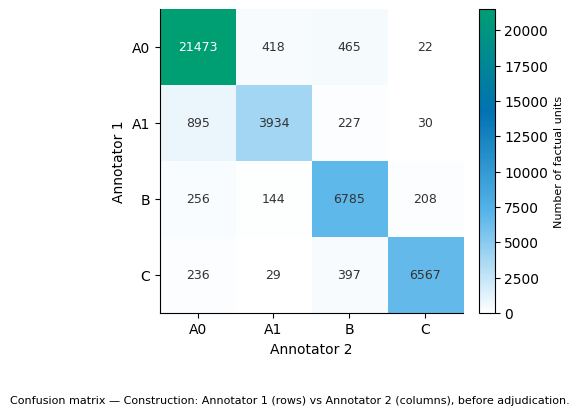


=== Chemistry--plastics ===


run_partial,A0,A1,B,C
run_all,,,,
A0,3223,79,76,3
A1,187,515,70,6
B,46,20,762,22
C,50,6,90,975


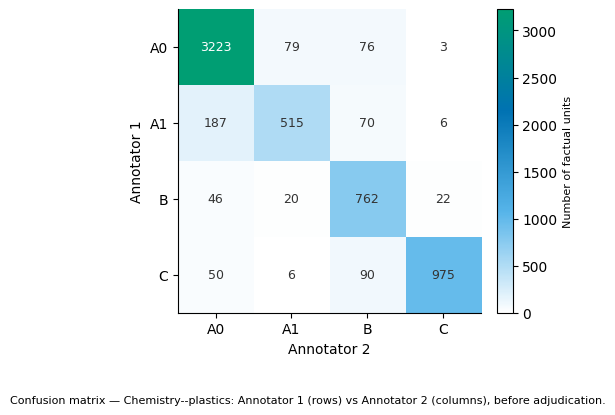


=== Metallurgy ===


run_partial,A0,A1,B,C
run_all,,,,
A0,11627,271,268,10
A1,580,1868,219,16
B,185,78,3063,106
C,149,24,265,3623


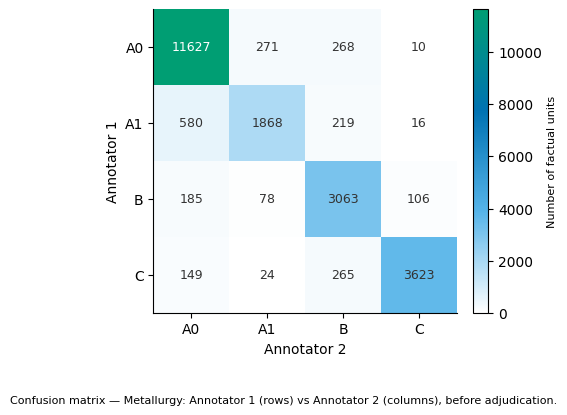


=== Company corpus ===


run_partial,A0,A1,B,C
run_all,,,,
A0,3033,16,21,8
A1,40,168,13,1
B,59,27,2487,33
C,13,0,378,3242


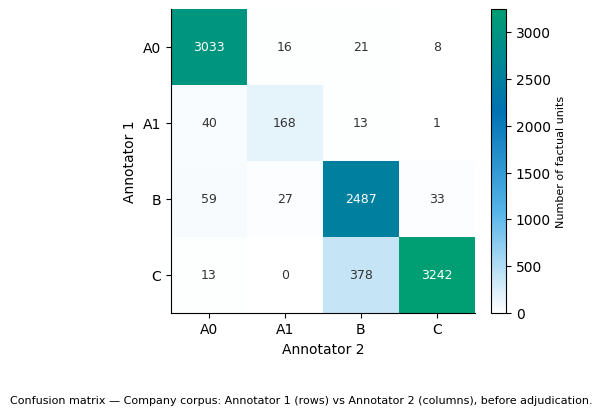


=== Overall ===


run_partial,A0,A1,B,C
run_all,,,,
A0,39356,784,830,43
A1,1702,6485,529,53
B,546,269,13097,369
C,448,59,1130,14407


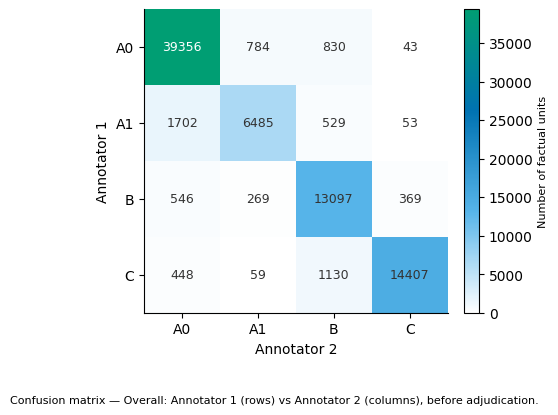

In [8]:
# --- Matrices de confusion (run_all × run_partial) ---
import matplotlib.pyplot as plt
import numpy as np

# Même palette Okabe–Ito que le barplot de distribution.
_iaa_cmap = article_confusion_cmap()

if not confusion_matrices:
    print("Pas de matrice de confusion (aucune paire).")
else:
    latex_confusions = {}
    for corpus_name, cm in confusion_matrices.items():
        print(f"\n=== {corpus_name} ===")
        display(cm)
        latex_confusions[corpus_name] = export_confusion_latex(cm, corpus=corpus_name)

        fig, ax = plt.subplots(figsize=(5.2, 4.6))
        data = cm.to_numpy(dtype=float)
        im = ax.imshow(data, cmap=_iaa_cmap, vmin=0)
        ax.set_xticks(range(len(cm.columns)))
        ax.set_yticks(range(len(cm.index)))
        ax.set_xticklabels(cm.columns)
        ax.set_yticklabels(cm.index)
        ax.set_xlabel("Annotator 2")
        ax.set_ylabel("Annotator 1")
        thresh = data.max() * 0.55 if data.max() > 0 else 0.5
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                val = int(cm.iloc[i, j])
                ax.text(
                    j,
                    i,
                    str(val),
                    ha="center",
                    va="center",
                    fontsize=9,
                    color="white" if data[i, j] > thresh else "#333333",
                )
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("Number of factual units", fontsize=8)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        fig.subplots_adjust(bottom=0.22)
        fig.text(
            0.5,
            0.02,
            f"Confusion matrix — {corpus_name}: Annotator 1 (rows) vs "
            "Annotator 2 (columns), before adjudication.",
            ha="center",
            va="bottom",
            fontsize=8,
        )
        plt.show()


### Annotator disagreements (all corpora)

Unités où Annotator 1 (`run_all`) et Annotator 2 (`run_partial`) divergent
sur le rôle (`A0`/`A1`/`B`/`C`), pour **chaque** corpus apparié.


In [9]:
# --- Tous les désaccords : tous les corpus ---
show_cols = [
    "corpus",
    "accident_id",
    "fact_id",
    "sentence",
    "accident_summary",
    "label_all",
    "label_partial",
    "disagreement",
    "justification_all",
    "justification_partial",
]

if not disagreements_by_corpus:
    print("Aucun désaccord (aucune paire ou accord parfait).")
    summary_disagreements_all = pd.DataFrame()
else:
    summary_rows = []
    for corpus_name, dd_df in disagreements_by_corpus.items():
        print(f"\n=== {corpus_name} — désaccords ({len(dd_df)} units) ===")
        if dd_df.empty:
            print("  (aucun désaccord)")
            continue
        summary_c = (
            dd_df.groupby("disagreement", dropna=False)
            .size()
            .reset_index(name="n_units")
            .sort_values("n_units", ascending=False)
        )
        summary_c.insert(0, "corpus", corpus_name)
        summary_rows.append(summary_c)
        display(summary_c)
        cols = [c for c in show_cols if c in dd_df.columns]
        display(dd_df[cols])
    summary_disagreements_all = (
        pd.concat(summary_rows, ignore_index=True) if summary_rows else pd.DataFrame()
    )
    if not all_disagreements.empty:
        print(f"\nTotal désaccords (tous corpus) : {len(all_disagreements)}")
        if not summary_disagreements_all.empty:
            print("Résumé agrégé :")
            display(summary_disagreements_all)



=== Construction — désaccords (3327 units) ===


,corpus,disagreement,n_units
3,Construction,A1 → A0,895
1,Construction,A0 → B,465
0,Construction,A0 → A1,418
11,Construction,C → B,397
6,Construction,B → A0,256
9,Construction,C → A0,236
4,Construction,A1 → B,227
8,Construction,B → C,208
7,Construction,B → A1,144
5,Construction,A1 → C,30


,corpus,accident_id,fact_id,sentence,accident_summary,label_all,label_partial,disagreement,justification_all,justification_partial
0,Construction,EB16DB93EC8D4705C1258D7A002EF784,1,L'accident de travail a eu lieu sur un chantie...,L'accident de travail a eu lieu sur un chantie...,A0,B,A0 → B,Indique uniquement le contexte et le lieu de l...,Contexte utilisé: non. Indice principal: « L'a...
1,Construction,EB16DB93EC8D4705C1258D7A002EF784,6,Quatre personnes sont présentes sur le chantie...,L'accident de travail a eu lieu sur un chantie...,A0,B,A0 → B,Indication de contexte et acteurs : « Quatre p...,Unité factuelle: « Quatre personnes sont prése...
2,Construction,CF6AC39FFB6F84B6C1258D79003A33A8,13,Le bâtiment est situé à proximité dune ligne ...,"Un couvreur de 43 ans, sous-traitant 1 de len...",A0,A1,A0 → A1,Contexte utilisé: non. Indice principal: « Le ...,L'unité factuelle « Le bâtiment est situé à pr...
3,Construction,CF6AC39FFB6F84B6C1258D79003A33A8,19,Le bâtiment est traversé par une ligne électri...,"Un couvreur de 43 ans, sous-traitant 1 de len...",A0,A1,A0 → A1,Indice principal: « non précisé ». Indication ...,Unité décrite: Le bâtiment est traversé par un...
4,Construction,CF6AC39FFB6F84B6C1258D79003A33A8,21,La ligne électrique se situerait à 12 mètres e...,"Un couvreur de 43 ans, sous-traitant 1 de len...",A0,A1,A0 → A1,Indice principal: « non précisé ». Contexte ut...,"Contexte utilisé: non. Indice principal: ""La l..."
...,...,...,...,...,...,...,...,...,...,...
3322,Construction,68936017820B2745C125719D0050B8C5,42256,Elle ne fut pas blessée.,"La victime - 50 ans, peintre sableur - se trou...",C,A0,C → A0,Indice principal: « non précisé ». Indication ...,Contexte utilisé: non. Indice principal: « Ell...
3323,Construction,20A2760CEDD3D7D7C125719D0050B9D5,42262,La tempête de vent est montée en puissance.,"La grue *** à tour (modèle ***, mise en servic...",A1,A0,A1 → A0,Indice principal: « La tempête de vent est mon...,Unité: « La tempête de vent est montée en puis...
3324,Construction,20A2760CEDD3D7D7C125719D0050B9D5,42268,Les trois autres personnes sont indemnes.,"La grue *** à tour (modèle ***, mise en servic...",C,A0,C → A0,Indice principal: « non précisé ». Indique exp...,Unité factuelle: Les trois autres personnes so...
3325,Construction,906ACED21178AFDAC125719D0050B77F,42290,Le bout de la flèche heurta l'acrotère d'un bâ...,"Ce chantier est équipé d'une grue à tour, de m...",B,C,B → C,Indique un événement accidentel: « Le bout de ...,« Le bout de la flèche heurta l'acrotère d'un ...



=== Chemistry--plastics — désaccords (655 units) ===


,corpus,disagreement,n_units
3,Chemistry--plastics,A1 → A0,187
11,Chemistry--plastics,C → B,90
0,Chemistry--plastics,A0 → A1,79
1,Chemistry--plastics,A0 → B,76
4,Chemistry--plastics,A1 → B,70
9,Chemistry--plastics,C → A0,50
6,Chemistry--plastics,B → A0,46
8,Chemistry--plastics,B → C,22
7,Chemistry--plastics,B → A1,20
5,Chemistry--plastics,A1 → C,6


...


=== Overall — désaccords (6762 units) ===


,corpus,disagreement,n_units
3,Overall,A1 → A0,1702
11,Overall,C → B,1130
1,Overall,A0 → B,830
0,Overall,A0 → A1,784
6,Overall,B → A0,546
4,Overall,A1 → B,529
9,Overall,C → A0,448
8,Overall,B → C,369
7,Overall,B → A1,269
10,Overall,C → A1,59


,corpus,accident_id,fact_id,sentence,accident_summary,label_all,label_partial,disagreement,justification_all,justification_partial
0,Overall,EB16DB93EC8D4705C1258D7A002EF784,1,L'accident de travail a eu lieu sur un chantie...,L'accident de travail a eu lieu sur un chantie...,A0,B,A0 → B,Indique uniquement le contexte et le lieu de l...,Contexte utilisé: non. Indice principal: « L'a...
1,Overall,EB16DB93EC8D4705C1258D7A002EF784,6,Quatre personnes sont présentes sur le chantie...,L'accident de travail a eu lieu sur un chantie...,A0,B,A0 → B,Indication de contexte et acteurs : « Quatre p...,Unité factuelle: « Quatre personnes sont prése...
2,Overall,CF6AC39FFB6F84B6C1258D79003A33A8,13,Le bâtiment est situé à proximité dune ligne ...,"Un couvreur de 43 ans, sous-traitant 1 de len...",A0,A1,A0 → A1,Contexte utilisé: non. Indice principal: « Le ...,L'unité factuelle « Le bâtiment est situé à pr...
3,Overall,CF6AC39FFB6F84B6C1258D79003A33A8,19,Le bâtiment est traversé par une ligne électri...,"Un couvreur de 43 ans, sous-traitant 1 de len...",A0,A1,A0 → A1,Indice principal: « non précisé ». Indication ...,Unité décrite: Le bâtiment est traversé par un...
4,Overall,CF6AC39FFB6F84B6C1258D79003A33A8,21,La ligne électrique se situerait à 12 mètres e...,"Un couvreur de 43 ans, sous-traitant 1 de len...",A0,A1,A0 → A1,Indice principal: « non précisé ». Contexte ut...,"Contexte utilisé: non. Indice principal: ""La l..."
...,...,...,...,...,...,...,...,...,...,...
6757,Overall,5843,9496,L'intérimaire déclare que le mécanisme s'est a...,La victime cherchait à résoudre une panne de l...,C,B,C → B,Indicateur de dommage explicite : « sa main ga...,Contexte utilisé: non. Indice principal: « le ...
6758,Overall,5845,9500,Le salarié déclare qu'en vidant une chiase en ...,Le salarié collectait des encombrants.\nLe sal...,C,B,C → B,Contexte utilisé: non. Indice principal: « il ...,Contexte utilisé: non. Indice principal: « il ...
6759,Overall,5847,9505,La salariée déclare qu'elle a inhalé des vapeu...,La salariée pénétrait dans un local stockage d...,B,A1,B → A1,Contexte utilisé: non. Indice principal: « a i...,Contexte utilisé: non. Indice principal: « vap...
6760,Overall,5848,9507,Le salarié déclare qu'il aurait ressenti un cr...,Le salarié effectuait la collecte d'ordures mé...,C,A0,C → A0,Contexte utilisé: non. Indice principal: « aur...,Contexte utilisé: non. Indice principal: « en ...



Total désaccords (tous corpus) : 13524
Résumé agrégé :


,corpus,disagreement,n_units
0,Construction,A1 → A0,895
1,Construction,A0 → B,465
2,Construction,A0 → A1,418
3,Construction,C → B,397
4,Construction,B → A0,256
5,Construction,C → A0,236
6,Construction,A1 → B,227
7,Construction,B → C,208
8,Construction,B → A1,144
9,Construction,A1 → C,30


In [10]:
# --- Export optionnel (CSV / XLSX / LaTeX) ---
export_dir = OUTPUTS_DIR / "_article_exports"
export_dir.mkdir(parents=True, exist_ok=True)

article_xlsx = export_dir / "annotation_corpus_summary.xlsx"
article_csv = export_dir / "annotation_corpus_summary.csv"
article_table.to_excel(article_xlsx, index=False)
article_table.to_csv(article_csv, index=False, encoding="utf-8-sig")

print("Exporté :")
print(" ", article_xlsx)
print(" ", article_csv)

if agreement_table is not None:
    agree_csv = export_dir / "annotation_agreement.csv"
    agree_xlsx = export_dir / "annotation_agreement.xlsx"
    agree_tex = export_dir / "annotation_agreement.tex"
    agreement_table.to_csv(agree_csv, index=False, encoding="utf-8-sig")
    agreement_table.to_excel(agree_xlsx, index=False)
    agree_tex.write_text(latex_agreement or "", encoding="utf-8")
    print(" ", agree_csv)
    print(" ", agree_xlsx)
    print(" ", agree_tex)

if confusion_matrices:
    for corpus_name, cm in confusion_matrices.items():
        slug = "".join(ch if ch.isalnum() else "_" for ch in corpus_name.lower())
        cm_csv = export_dir / f"annotation_confusion_{slug}.csv"
        cm_xlsx = export_dir / f"annotation_confusion_{slug}.xlsx"
        cm_tex = export_dir / f"annotation_confusion_{slug}.tex"
        cm.to_csv(cm_csv, encoding="utf-8-sig")
        cm.to_excel(cm_xlsx)
        cm_tex.write_text(
            latex_confusions.get(corpus_name, export_confusion_latex(cm, corpus=corpus_name)),
            encoding="utf-8",
        )
        print(" ", cm_csv)
        print(" ", cm_xlsx)
        print(" ", cm_tex)

if disagreements_by_corpus:
    all_units = []
    all_summaries = []
    for corpus_name, dd_df in disagreements_by_corpus.items():
        slug = "".join(ch if ch.isalnum() else "_" for ch in corpus_name.lower())
        dd_xlsx = export_dir / f"annotation_disagreements_{slug}.xlsx"
        dd_csv = export_dir / f"annotation_disagreements_{slug}.csv"
        summary_c = (
            dd_df.groupby("disagreement", dropna=False)
            .size()
            .reset_index(name="n_units")
            .sort_values("n_units", ascending=False)
            if not dd_df.empty
            else pd.DataFrame(columns=["disagreement", "n_units"])
        )
        with pd.ExcelWriter(dd_xlsx, engine="openpyxl") as writer:
            summary_c.to_excel(writer, sheet_name="summary", index=False)
            dd_df.to_excel(writer, sheet_name="units", index=False)
        dd_df.to_csv(dd_csv, index=False, encoding="utf-8-sig")
        print(" ", dd_xlsx)
        print(" ", dd_csv)
        if not dd_df.empty:
            all_units.append(dd_df)
            s = summary_c.copy()
            s.insert(0, "corpus", corpus_name)
            all_summaries.append(s)

    if all_units:
        dd_all_xlsx = export_dir / "annotation_disagreements_all.xlsx"
        dd_all_csv = export_dir / "annotation_disagreements_all.csv"
        units_all = pd.concat(all_units, ignore_index=True)
        summary_all = pd.concat(all_summaries, ignore_index=True)
        with pd.ExcelWriter(dd_all_xlsx, engine="openpyxl") as writer:
            summary_all.to_excel(writer, sheet_name="summary", index=False)
            units_all.to_excel(writer, sheet_name="units", index=False)
        units_all.to_csv(dd_all_csv, index=False, encoding="utf-8-sig")
        print(" ", dd_all_xlsx)
        print(" ", dd_all_csv)


Exporté :
  C:\Users\aho\Documents\analysis factor project\SAFER\text\annotation\outputs\_article_exports\annotation_corpus_summary.xlsx
  C:\Users\aho\Documents\analysis factor project\SAFER\text\annotation\outputs\_article_exports\annotation_corpus_summary.csv
  C:\Users\aho\Documents\analysis factor project\SAFER\text\annotation\outputs\_article_exports\annotation_agreement.csv
  C:\Users\aho\Documents\analysis factor project\SAFER\text\annotation\outputs\_article_exports\annotation_agreement.xlsx
  C:\Users\aho\Documents\analysis factor project\SAFER\text\annotation\outputs\_article_exports\annotation_agreement.tex
  C:\Users\aho\Documents\analysis factor project\SAFER\text\annotation\outputs\_article_exports\annotation_confusion_construction.csv
  C:\Users\aho\Documents\analysis factor project\SAFER\text\annotation\outputs\_article_exports\annotation_confusion_construction.xlsx
  C:\Users\aho\Documents\analysis factor project\SAFER\text\annotation\outputs\_article_exports\annotati